# Comparison of Research Papers

This section will contain the code and analysis for comparing the two research papers: "An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale" and "BiSeNet: Bilateral Segmentation Network for Real-time Semantic Segmentation." A detailed summary of the comparison will follow the code.

In [ ]:
!pip -q install torch torchvision torchaudio timm tqdm

import os, random, time, math, sys, platform
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt

def device_select():
    if torch.cuda.is_available(): return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available(): return "mps"
    return "cpu"

DEVICE = device_select()
DEVICE

'cuda'

In [ ]:
# Configurations
USE_CIFAR10 = True  #@param {type:"boolean"}  # False = use a custom dataset from Drive
CUSTOM_DATA_DIR = "/content/sample_data"  #@param {type:"string"}
IMG_SIZE = 224  #@param {type:"integer"}
BATCH_SIZE = 128  #@param {type:"integer"}
EPOCHS = 3  #@param {type:"integer"}
LR = 3e-4  #@param {type:"number"}
LINEAR_PROBE = False  #@param {type:"boolean"}  # True = freeze backbone; train head only
LIMIT_TRAIN_SAMPLES = 0  #@param {type:"integer"} # 0 = full; set small number for quick debug (e.g., 2000)
LIMIT_VAL_SAMPLES = 0  #@param {type:"integer"}

# Which models to run
RUN_RESNET50 = True   #@param {type:"boolean"}
RUN_VIT_B16  = True   #@param {type:"boolean"}
RUN_CONVNEXT_T = False  #@param {type:"boolean"}

SEED = 42


In [ ]:
#@title Reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = False  # deterministic=True slows, dont keep unless needed
    torch.backends.cudnn.benchmark = True


In [ ]:
#@title Mount Google Drive - for custom
if not USE_CIFAR10:
    from google.colab import drive
    drive.mount('/content/sample_data')
    print("Mounted. Using:", CUSTOM_DATA_DIR)


In [ ]:
#@title Build datasets and loaders
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD  = [0.229, 0.224, 0.225]

tfm_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

tfm_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
])

if USE_CIFAR10:
    train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm_train)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm_test)
    NUM_CLASSES = 10
else:
    train_root = os.path.join(CUSTOM_DATA_DIR, "train")
    val_root   = os.path.join(CUSTOM_DATA_DIR, "val")
    assert os.path.isdir(train_root), f"Missing {train_root}"
    assert os.path.isdir(val_root),   f"Missing {val_root}"

    train_ds = datasets.ImageFolder(train_root, transform=tfm_train)
    test_ds  = datasets.ImageFolder(val_root,   transform=tfm_test)
    NUM_CLASSES = len(train_ds.classes)

def maybe_subset(ds, limit):
    if limit and limit > 0:
        idx = np.random.RandomState(SEED).choice(len(ds), size=min(limit, len(ds)), replace=False)
        return Subset(ds, idx)
    return ds

train_ds_eff = maybe_subset(train_ds, LIMIT_TRAIN_SAMPLES)
test_ds_eff  = maybe_subset(test_ds, LIMIT_VAL_SAMPLES)

train_loader = DataLoader(train_ds_eff, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(test_ds_eff,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))

len(train_ds_eff), len(test_ds_eff), NUM_CLASSES


100%|██████████| 170M/170M [00:13<00:00, 12.2MB/s]


(50000, 10000, 10)

In [ ]:
#@title Model builders and head replacement
def build_resnet50(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    in_f = m.fc.in_features
    m.fc = nn.Linear(in_f, num_classes)
    return m

def build_vit_b16(num_classes):
    m = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    in_f = m.heads.head.in_features
    m.heads.head = nn.Linear(in_f, num_classes)
    return m

def build_convnext_tiny(num_classes):
    m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    in_f = m.classifier[2].in_features
    m.classifier[2] = nn.Linear(in_f, num_classes)
    return m

def freeze_backbone_for_linear_probe(model):
    # Freeze everything except the final classifier
    for p in model.parameters():
        p.requires_grad = False
    # Unfreeze classifier layers
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        model.fc.weight.requires_grad = True
        model.fc.bias.requires_grad = True
    if hasattr(model, "heads") and hasattr(model.heads, "head"):
        for p in model.heads.head.parameters():
            p.requires_grad = True
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
        for p in model.classifier[-1].parameters():
            p.requires_grad = True
    return model


In [ ]:
# Training/Eval
def train_one(model, loader, optimizer):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total += x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        loss_sum += loss.item() * x.size(0)
    return loss_sum / total, correct / total

@torch.inference_mode()
def eval_one(model, loader):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        total += x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        loss_sum += loss.item() * x.size(0)
    return loss_sum / total, correct / total

def run_experiment(build_fn, name):
    model = build_fn(NUM_CLASSES).to(DEVICE)
    if LINEAR_PROBE:
        model = freeze_backbone_for_linear_probe(model)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params     = sum(p.numel() for p in model.parameters())
    print(f"{name}: params={total_params/1e6:.1f}M | trainable={trainable_params/1e6:.1f}M | device={DEVICE}")

    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    tr_hist, te_hist = [], []
    t0 = time.time()
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one(model, train_loader, optimizer)
        te_loss, te_acc = eval_one(model, test_loader)
        tr_hist.append((tr_loss, tr_acc)); te_hist.append((te_loss, te_acc))
        print(f"[{name}] epoch {ep}/{EPOCHS} | train {tr_loss:.4f}/{tr_acc:.3f} | val {te_loss:.4f}/{te_acc:.3f}")
    elapsed = (time.time() - t0) / 60
    print(f"[{name}] done in {elapsed:.1f} min")

    return {
        "name": name,
        "train_hist": tr_hist,
        "val_hist": te_hist,
        "final_acc": te_hist[-1][1],
        "total_params": total_params,
        "trainable_params": trainable_params,
    }

def plot_histories(results):
    plt.figure(figsize=(6, 4))
    for r in results:
        accs = [a for (_, a) in r["val_hist"]]
        plt.plot(accs, label=r["name"])
    plt.xlabel("epoch"); plt.ylabel("val acc"); plt.title("Validation Accuracy")
    plt.legend(); plt.grid(True); plt.show()


In [ ]:
#@title Run selected models (verbose & safe)
print(f"RUN_RESNET50={RUN_RESNET50}, RUN_VIT_B16={RUN_VIT_B16}, RUN_CONVNEXT_T={RUN_CONVNEXT_T}")

results = []

try:
    if RUN_RESNET50:
        results.append(run_experiment(build_resnet50, "ResNet50"))
    if RUN_VIT_B16:
        results.append(run_experiment(build_vit_b16, "ViT-B/16"))
    if RUN_CONVNEXT_T:
        results.append(run_experiment(build_convnext_tiny, "ConvNeXt-T"))
except Exception as e:
    import traceback
    traceback.print_exc()
    raise

if not results:
    raise RuntimeError("No models ran. Enable at least one of RUN_RESNET50 / RUN_VIT_B16 / RUN_CONVNEXT_T.")

plot_histories(results)

# Nice summary table
import pandas as pd
pd.DataFrame([
    {
        "model": r["name"],
        "final_val_acc": round(r["final_acc"], 4),
        "params_M": round(r["total_params"]/1e6, 2),
        "trainable_M": round(r["trainable_params"]/1e6, 2),
        "epochs": EPOCHS,
        "img_size": IMG_SIZE,
        "batch": BATCH_SIZE,
        "linear_probe": LINEAR_PROBE,
    }
    for r in results
])


In [11]:
# For freeing the vram, resnet only filled 15GB of memory. I didnt have enough memory so I have only resnet results from above cell.
import gc, torch, os
gc.collect()
torch.cuda.empty_cache()

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

for name in ["model", "vit", "results", "optimizer"]:
    if name in globals():
        del globals()[name]
gc.collect()
torch.cuda.empty_cache()


ViT-B/16: params=85.8M | trainable=0.0M | device=cuda
[ViT-B/16] epoch 1/2 | train 0.4885/0.895 | val 0.2315/0.936
[ViT-B/16] epoch 2/2 | train 0.1993/0.941 | val 0.1875/0.944
[ViT-B/16] done in 22.1 min


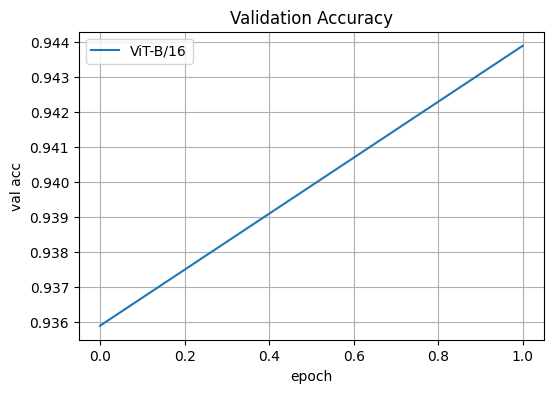

In [12]:
# rerun vit - if previously filled the gpu
IMG_SIZE = 160      # smaller input
BATCH_SIZE = 32     # smaller batch
LINEAR_PROBE = True # freeze backbone to cut memory
EPOCHS = 2          # short test run

results = []
results.append(run_experiment(build_vit_b16, "ViT-B/16"))
plot_histories(results)

ResNet50: params=23.5M | trainable=0.0M | device=cuda
[ResNet50] epoch 1/2 | train 1.2794/0.660 | val 0.8934/0.743
[ResNet50] epoch 2/2 | train 0.8132/0.757 | val 0.7356/0.769
[ResNet50] done in 6.0 min


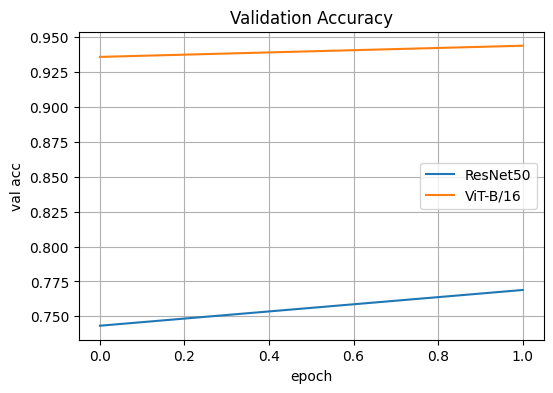

In [15]:
res_cnn = run_experiment(build_resnet50, "ResNet50")
results = [res_cnn] + results   # prepend the CNN
plot_histories(results)

In [16]:
#@title Summarize results
import pandas as pd

rows = []
for r in results:
    rows.append({
        "model": r["name"],
        "final_val_acc": round(r["final_acc"], 4),
        "params_M": round(r["total_params"]/1e6, 2),
        "trainable_M": round(r["trainable_params"]/1e6, 2),
        "epochs": EPOCHS,
        "img_size": IMG_SIZE,
        "batch": BATCH_SIZE,
        "linear_probe": LINEAR_PROBE,
        "dataset": "CIFAR10" if USE_CIFAR10 else os.path.basename(CUSTOM_DATA_DIR.rstrip("/")),
    })

df = pd.DataFrame(rows).sort_values("final_val_acc", ascending=False).reset_index(drop=True)
df


,model,final_val_acc,params_M,trainable_M,epochs,img_size,batch,linear_probe,dataset
0,ViT-B/16,0.9439,85.81,0.01,2,160,32,True,CIFAR10
1,ResNet50,0.7689,23.53,0.02,2,160,32,True,CIFAR10


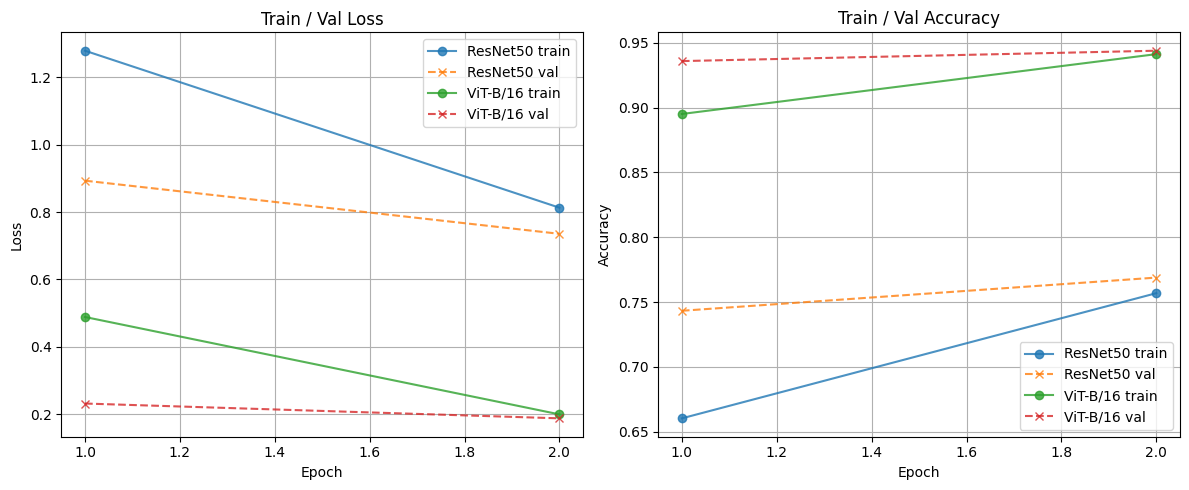

Saved results_summary.csv and training_curves.png


,model,best_epoch,best_val_acc,final_train_acc,final_val_acc,train_val_gap,params_M,trainable_M,epochs,img_size,batch,linear_probe
0,ViT-B/16,2,0.9439,0.9413,0.9439,-0.0026,85.81,0.01,2,160,32,True
1,ResNet50,2,0.7689,0.7569,0.7689,-0.0120,23.53,0.02,2,160,32,True


In [17]:
import pandas as pd

assert "results" in globals() and len(results) > 0, "No results found. Run the experiments first."

summary_rows = []
plt.figure(figsize=(12, 5))

# Plotting loss (left) and accuracy (right)
plt.subplot(1, 2, 1)
for r in results:
    tr_losses = [t for (t, _) in r["train_hist"]]
    val_losses = [t for (t, _) in r["val_hist"]]
    plt.plot(range(1, len(tr_losses) + 1), tr_losses, marker="o", linestyle="-", alpha=0.8, label=f"{r['name']} train")
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker="x", linestyle="--", alpha=0.8, label=f"{r['name']} val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Train / Val Loss"); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for r in results:
    tr_accs = [a for (_, a) in r["train_hist"]]
    val_accs = [a for (_, a) in r["val_hist"]]
    plt.plot(range(1, len(tr_accs) + 1), tr_accs, marker="o", linestyle="-", alpha=0.8, label=f"{r['name']} train")
    plt.plot(range(1, len(val_accs) + 1), val_accs, marker="x", linestyle="--", alpha=0.8, label=f"{r['name']} val")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Train / Val Accuracy"); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# Build summary dataframe with additional metrics
for r in results:
    tr_accs = [a for (_, a) in r["train_hist"]]
    val_accs = [a for (_, a) in r["val_hist"]]
    tr_losses = [t for (t, _) in r["train_hist"]]
    val_losses = [t for (t, _) in r["val_hist"]]

    best_epoch = int(np.argmax(val_accs)) + 1
    best_val_acc = float(max(val_accs))
    final_train_acc = float(tr_accs[-1])
    final_val_acc = float(val_accs[-1])
    train_val_gap = final_train_acc - final_val_acc
    avg_epoch_time_min = None  # not recorded; placeholder if needed

    summary_rows.append({
        "model": r["name"],
        "best_epoch": best_epoch,
        "best_val_acc": round(best_val_acc, 4),
        "final_train_acc": round(final_train_acc, 4),
        "final_val_acc": round(final_val_acc, 4),
        "train_val_gap": round(train_val_gap, 4),
        "params_M": round(r["total_params"]/1e6, 2),
        "trainable_M": round(r["trainable_params"]/1e6, 2),
        "epochs": EPOCHS,
        "img_size": IMG_SIZE,
        "batch": BATCH_SIZE,
        "linear_probe": LINEAR_PROBE,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
summary_df.to_csv("results_summary.csv", index=False)
print("Saved results_summary.csv and training_curves.png")
summary_df